## Charmonia Suppression in pPb LHC Collision due to nPDF: Centrality Dependence

### Importing CNM

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ------------------------------------------------------------------
# Project paths (edit ONLY if your folder layout differs)
# ------------------------------------------------------------------
ROOT = Path("../")                   # where "npdf_code/" and "input/" live
NPDF_CODE_DIR = ROOT / "npdf_code" # must contain: npdf_data.py, gluon_ratio.py, glauber.py, npdf_centrality.py

if str(NPDF_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(NPDF_CODE_DIR))

# ------------------------------------------------------------------
# npdf_code imports
# ------------------------------------------------------------------
from npdf_data import NPDFSystem, RpAAnalysis
from gluon_ratio import EPPS21Ratio, GluonEPPSProvider
from glauber import OpticalGlauber, SystemSpec
from npdf_centrality import (
    compute_df49_by_centrality,
    make_centrality_weight_dict,
    bin_rpa_vs_y,
    bin_rpa_vs_pT,
    bin_rpa_vs_centrality,
)

print("[OK] Imported npdf_code modules.")

[OK] Imported npdf_code modules.


In [2]:
# ------------------------------------------------------------------
# Output toggles
# ------------------------------------------------------------------
SAVE_PDF   = True
SAVE_CSV   = True
DPI        = 150
ALPHA_BAND = 0.22

# ------------------------------------------------------------------
# Energy choice
# ------------------------------------------------------------------
ENERGY = "5.02"  # "5.02" or "8.16"

# ------------------------------------------------------------------
# Centrality bins (edit freely)
# ------------------------------------------------------------------
CENT_BINS = [(0,10),(10,20),(20,40),(40,60),(60,80),(80,100)]
# CENT_BINS = [(0,20),(20,40),(40,60),(60,80),(80,100)]

# ------------------------------------------------------------------
# Binning (edit freely)
# ------------------------------------------------------------------
Y_EDGES = np.arange(-5.5, 5.0 + 0.5, 0.5)
P_EDGES = np.arange(0.0, 20.0 + 2.5, 2.5)

Y_WINDOWS = [
    (-4.46, -2.96, "-4.46 < y < -2.96"),
    (-1.37,  0.43, "-1.37 < y < 0.43"),
    ( 2.03,  3.53, "2.03 < y < 3.53"),
]

PT_RANGE_AVG = (0.0, 15.0)  # used for RpA(y) and RpA(cent)
PT_FLOOR_W   = 1.0          # low-pT weight floor (same idea as your CNM notebook)

# ------------------------------------------------------------------
# nPDF weighting knobs (KEEP FLEXIBLE)
# ------------------------------------------------------------------
WEIGHT_MODE      = "pp@local"
Y_REF            = 0.0
NB_BSAMPLES      = 5
Y_SHIFT_FRACTION = 2.0       # IMPORTANT knob you requested
MB_C0            = 0.25      # exp-weight parameter used for MB (same style as CNM notebook)

# ------------------------------------------------------------------
# Input locations (match your cnm_combine defaults)
# ------------------------------------------------------------------
NPDF_INPUT_DIR = ROOT / "input" / "npdf"
P5_DIR   = NPDF_INPUT_DIR / "pPb5TeV"
P8_DIR   = NPDF_INPUT_DIR / "pPb8TeV"
EPPS_DIR = NPDF_INPUT_DIR / "nPDFs"

SQRTS_GEV = {"5.02": 5023.0, "8.16": 8160.0}
SIG_NN_MB = {"5.02": 67.0,   "8.16": 71.0}

OUTDIR = ROOT / f"output-npdf-only-{ENERGY.replace('.','p')}"
OUTDIR.mkdir(exist_ok=True, parents=True)

print(f"[CFG] ENERGY={ENERGY} TeV, OUTDIR={OUTDIR}")

[CFG] ENERGY=5.02 TeV, OUTDIR=../output-npdf-only-5p02


In [3]:
## Loaders and builders
def build_npdf_context(
    energy: str,
    cent_bins,
    nb_bsamples: int = NB_BSAMPLES,
    y_shift_fraction: float = Y_SHIFT_FRACTION,
    pt_floor_w: float = PT_FLOOR_W,
    m_state_for_np="charmonium",   # <-- charmonia notebook; set to 3.0969 if you want J/psi mass explicitly
):
    if energy not in SQRTS_GEV:
        raise ValueError("energy must be '5.02' or '8.16'")

    sqrt_sNN = SQRTS_GEV[energy]
    sigma_nn_mb = SIG_NN_MB[energy]
    input_dir = P5_DIR if energy == "5.02" else P8_DIR

    # EPPS21 ratio + gluon provider
    epps_ratio = EPPS21Ratio(A=208, path=str(EPPS_DIR))
    gluon = GluonEPPSProvider(
        epps_ratio,
        sqrt_sNN_GeV=sqrt_sNN,
        m_state_GeV=m_state_for_np,
        y_sign_for_xA=-1,
    )

    # Optical Glauber for pA
    gl_pA = OpticalGlauber(
        SystemSpec("pA", sqrt_sNN, A=208, sigma_nn_mb=sigma_nn_mb),
        verbose=False,
    )

    # Load TopDrawer nPDF tables
    sys_npdf = NPDFSystem.from_folder(
        str(input_dir),
        kick="pp",
        name=f"p+Pb {energy} TeV",
    )

    # Build RpA grid + Hessian members
    ana = RpAAnalysis()
    base, r0, M = ana.compute_rpa_members(
        sys_npdf.df_pp,
        sys_npdf.df_pa,
        sys_npdf.df_errors,
        join="intersect",
        lowpt_policy="drop",
        pt_shift_min=pt_floor_w,
        shift_if_r_below=0.0,
    )

    # Centrality dependence: df49 for each centrality bin
    df49_by_cent, K_by_cent, SA_all, Y_SHIFT = compute_df49_by_centrality(
        base, r0, M,
        gluon, gl_pA,
        cent_bins=cent_bins,
        nb_bsamples=nb_bsamples,
        y_shift_fraction=y_shift_fraction,
    )

    return dict(
        energy=energy,
        sqrt_sNN=sqrt_sNN,
        sigma_nn_mb=sigma_nn_mb,
        cent_bins=cent_bins,
        df49_by_cent=df49_by_cent,
        df_pp=sys_npdf.df_pp,
        df_pa=sys_npdf.df_pa,
        gluon=gluon,
        gl=gl_pA,
        K_by_cent=K_by_cent,
        SA_all=SA_all,
        Y_SHIFT=Y_SHIFT,
    )

ctx = build_npdf_context(ENERGY, CENT_BINS)
print(f"[OK] Built nPDF context for √sNN={ctx['sqrt_sNN']/1000:.2f} TeV, bins={len(CENT_BINS)}, Y_SHIFT={ctx['Y_SHIFT']}")


[OK] Built nPDF context for √sNN=5.02 TeV, bins=6, Y_SHIFT=1.0


In [4]:
## Helpers
def tags_for_cent_bins(cent_bins, include_mb=True):
    tags = [f"{int(a)}-{int(b)}%" for (a,b) in cent_bins]
    if include_mb:
        tags.append("MB")
    return tags

def step_from_centers(x_cent, vals):
    x_cent = np.asarray(x_cent, float)
    vals = np.asarray(vals, float)
    assert x_cent.size == vals.size
    if x_cent.size > 1:
        dx = np.diff(x_cent)
        if not np.allclose(dx, dx[0]):
            raise ValueError("x_cent not uniformly spaced; provide edges instead.")
        dx0 = dx[0]
    else:
        dx0 = 1.0
    x_edges = np.concatenate(([x_cent[0] - 0.5*dx0], x_cent + 0.5*dx0))
    y_step  = np.concatenate([vals, vals[-1:]])
    return x_edges, y_step

def cent_step_arrays(cent_bins, vals):
    vals = np.asarray(vals, float)
    edges = [cent_bins[0][0]] + [b for (_, b) in cent_bins]
    x_edges = np.asarray(edges, float)
    y_step = np.concatenate([vals, vals[-1:]])
    return x_edges, y_step

def ncoll_by_cent_bins(ctx, optical=True):
    gl = ctx["gl"]
    fn = gl.ncoll_mean_bin_pA_optical if optical else gl.ncoll_mean_bin_pA
    ncoll = [fn(a/100.0, b/100.0) for (a,b) in ctx["cent_bins"]]
    ncoll_mb = fn(0.0, 1.0)
    return np.asarray(ncoll, float), float(ncoll_mb)

def df_vs_y(y_cent, bands, tags):
    rows=[]
    for tag in tags:
        Rc,Rlo,Rhi = bands[tag]
        for y, rc, lo, hi in zip(y_cent, Rc, Rlo, Rhi):
            rows.append(dict(y_center=float(y), centrality=tag, is_MB=(tag=="MB"),
                             R_central=float(rc), R_lo=float(lo), R_hi=float(hi)))
    return pd.DataFrame(rows)

def df_vs_pT(pT_cent, bands, tags):
    rows=[]
    for tag in tags:
        Rc,Rlo,Rhi = bands[tag]
        for p, rc, lo, hi in zip(pT_cent, Rc, Rlo, Rhi):
            rows.append(dict(pT_center=float(p), centrality=tag, is_MB=(tag=="MB"),
                             R_central=float(rc), R_lo=float(lo), R_hi=float(hi)))
    return pd.DataFrame(rows)

def df_vs_cent(ctx, labels, Rc, Rlo, Rhi, mb, ncoll=None, ncoll_mb=None):
    rows=[]
    for i, ((cL,cR), lab) in enumerate(zip(ctx["cent_bins"], labels)):
        rows.append(dict(
            cent_left=float(cL), cent_right=float(cR), cent_label=lab, is_MB=False,
            Ncoll=float(ncoll[i]) if ncoll is not None else np.nan,
            R_central=float(Rc[i]), R_lo=float(Rlo[i]), R_hi=float(Rhi[i])
        ))
    rows.append(dict(
        cent_left=float(ctx["cent_bins"][0][0]), cent_right=float(ctx["cent_bins"][-1][1]),
        cent_label="MB", is_MB=True,
        Ncoll=float(ncoll_mb) if ncoll_mb is not None else np.nan,
        R_central=float(mb[0]), R_lo=float(mb[1]), R_hi=float(mb[2])
    ))
    return pd.DataFrame(rows)

## $R_{pA}$ vs Centrality

In [5]:
def npdf_vs_centrality(ctx, y_window, pt_range_avg, mb_c0=MB_C0):
    y0, y1 = y_window
    wcent = make_centrality_weight_dict(ctx["cent_bins"], c0=mb_c0)
    width_weights = np.array([wcent[f"{int(a)}-{int(b)}%"] for (a,b) in ctx["cent_bins"]], float)

    out = bin_rpa_vs_centrality(
        ctx["df49_by_cent"], ctx["df_pp"], ctx["df_pa"], ctx["gluon"],
        cent_bins=ctx["cent_bins"],
        y_window=(y0, y1),
        pt_range_avg=pt_range_avg,
        weight_mode=WEIGHT_MODE,
        y_ref=Y_REF,
        pt_floor_w=PT_FLOOR_W,
        width_weights=width_weights,
    )

    labels = [f"{int(a)}-{int(b)}%" for (a,b) in ctx["cent_bins"]]
    Rc  = np.asarray(out["r_central"], float)
    Rlo = np.asarray(out["r_lo"], float)
    Rhi = np.asarray(out["r_hi"], float)
    mb  = (float(out["mb_r_central"]), float(out["mb_r_lo"]), float(out["mb_r_hi"]))
    return labels, Rc, Rlo, Rhi, mb

[Ncoll] bins: [14.067 12.853 10.651  7.119  3.734  1.618] MB: 7.214


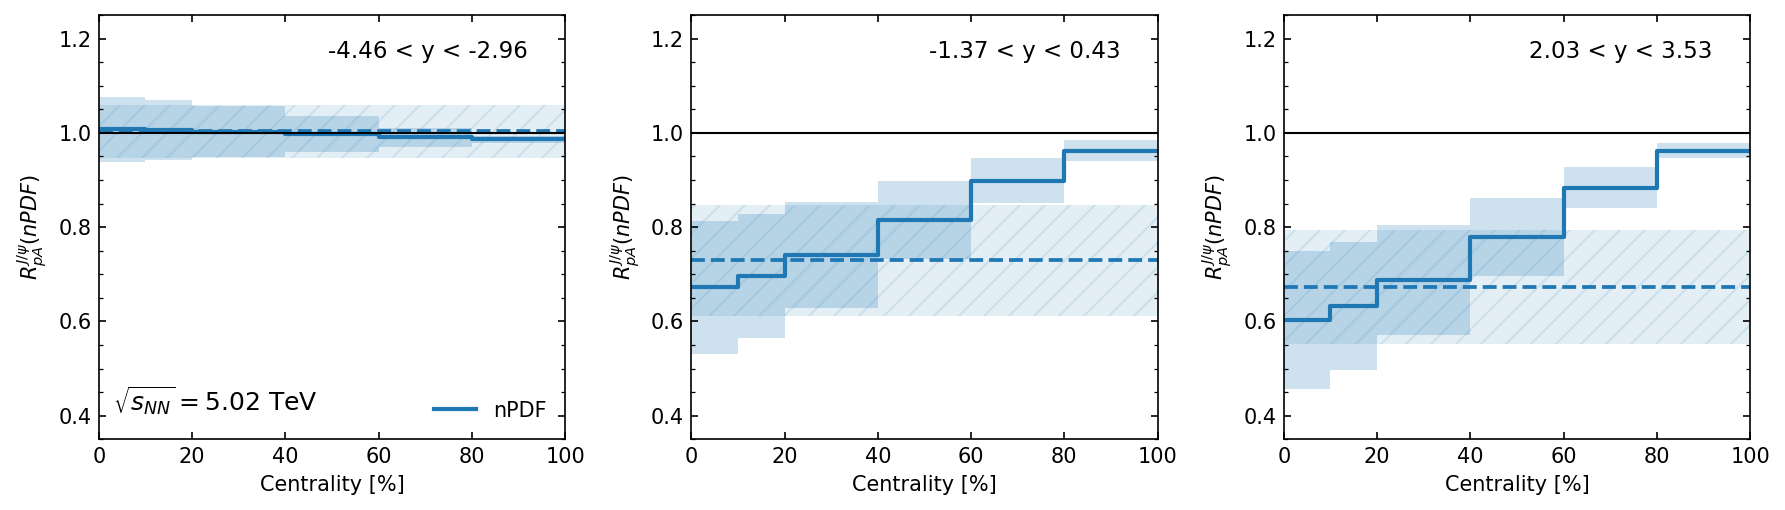

In [6]:
# Ncoll mapping (optical default)
Ncoll_cent, Ncoll_MB = ncoll_by_cent_bins(ctx, optical=True)
print("[Ncoll] bins:", np.round(Ncoll_cent, 3), "MB:", round(Ncoll_MB, 3))

npdf_cent_all = {}

# --- Step plot vs centrality ---
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5), dpi=DPI, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, (y0, y1, name) in zip(axes, Y_WINDOWS):
    labels, Rc, Rlo, Rhi, mb = npdf_vs_centrality(ctx, (y0,y1), PT_RANGE_AVG)
    npdf_cent_all[name] = (labels, Rc, Rlo, Rhi, mb)

    if SAVE_CSV:
        safe_name = name.replace(" ", "").replace("<","").replace(">","")
        dfc = df_vs_cent(ctx, labels, Rc, Rlo, Rhi, mb, ncoll=Ncoll_cent, ncoll_mb=Ncoll_MB)
        dfc.to_csv(OUTDIR / f"RpA_nPDF_vs_centrality_{safe_name}_{ENERGY.replace('.','p')}TeV.csv", index=False)

    x_edges, y_c  = cent_step_arrays(ctx["cent_bins"], Rc)
    _,       y_lo = cent_step_arrays(ctx["cent_bins"], Rlo)
    _,       y_hi = cent_step_arrays(ctx["cent_bins"], Rhi)

    ax.step(x_edges, y_c, where="post", lw=2.0, color="tab:blue", label="nPDF" if ax is axes[0] else None)
    ax.fill_between(x_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=ALPHA_BAND, linewidth=0.0)
    
    # MB dashed band (same color as nPDF)
    mb_c, mb_lo, mb_hi = mb
    ax.fill_between(
        [0.0, 100.0],
        [mb_lo, mb_lo],
        [mb_hi, mb_hi],
        color="tab:blue",
        alpha=0.12,
        hatch="//",
        linewidth=0.0,
    )
    ax.hlines(
        mb_c, 0.0, 100.0,
        colors="tab:blue",
        linestyles="--",
        linewidth=1.8,
    )

    ax.text(0.92, 0.94, name, transform=ax.transAxes, ha="right", va="top", fontsize=11)
    if ax is axes[0]:
        ax.text(0.03, 0.05, rf"$\sqrt{{s_{{NN}}}}={ctx['sqrt_sNN']/1000:.2f}$ TeV", transform=ax.transAxes,
                ha="left", va="bottom", fontsize=12)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.axhline(1.0, color="k", ls="-", lw=1.0)

    ax.set_xlabel("Centrality [%]")
    ax.set_ylabel(r"$R^{J/\psi}_{pA} (nPDF)$")
    ax.set_xlim(0, 100)
    ax.set_ylim(0.35, 1.25)
    ax.set_title("")

axes[0].legend(loc="lower right", frameon=False)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(OUTDIR / f"RpA_nPDF_vs_centrality_{ENERGY.replace('.','p')}TeV.pdf", bbox_inches="tight")
plt.show()

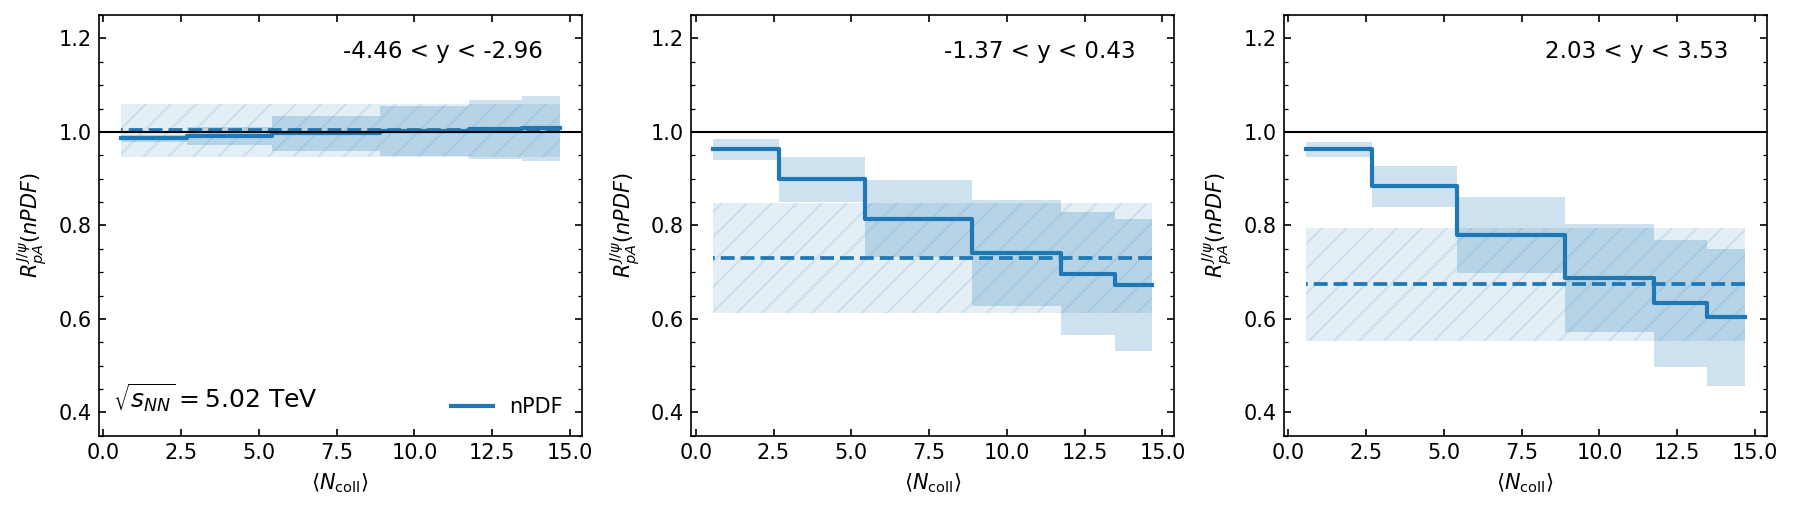

In [7]:
def edges_from_centers(xc):
    xc = np.asarray(xc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float)
    mids = 0.5*(xc[:-1] + xc[1:])
    left = xc[0] - (mids[0] - xc[0])
    right = xc[-1] + (xc[-1] - mids[-1])
    return np.concatenate([[left], mids, [right]])

# --- Step+band vs <Ncoll> ---
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5), dpi=DPI, sharey=False)
axes = np.atleast_1d(axes).ravel()

xN_edges = edges_from_centers(Ncoll_cent)

for ax, (y0, y1, name) in zip(axes, Y_WINDOWS):
    labels, Rc, Rlo, Rhi, mb = npdf_cent_all[name]
    mb_c, mb_lo, mb_hi = mb

    # main band as step vs Ncoll
    y_c  = np.concatenate([Rc,  Rc[-1:]])
    y_lo = np.concatenate([Rlo, Rlo[-1:]])
    y_hi = np.concatenate([Rhi, Rhi[-1:]])

    ax.step(xN_edges, y_c, where="post", lw=2.0, color="tab:blue", label="nPDF" if ax is axes[0] else None)
    ax.fill_between(xN_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=ALPHA_BAND, linewidth=0.0)

    # MB dashed band (same color)
    ax.fill_between(
        [xN_edges[0], xN_edges[-1]],
        [mb_lo, mb_lo],
        [mb_hi, mb_hi],
        color="tab:blue",
        alpha=0.12,
        hatch="//",
        linewidth=0.0,
    )
    ax.hlines(
        mb_c, xN_edges[0], xN_edges[-1],
        colors="tab:blue",
        linestyles="--",
        linewidth=1.8,
    )

    ax.text(0.92, 0.94, name, transform=ax.transAxes, ha="right", va="top", fontsize=11)
    if ax is axes[0]:
        ax.text(0.03, 0.05, rf"$\sqrt{{s_{{NN}}}}={ctx['sqrt_sNN']/1000:.2f}$ TeV",
                transform=ax.transAxes, ha="left", va="bottom", fontsize=12)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.axhline(1.0, color="k", ls="-", lw=1.0)

    ax.set_xlabel(r"$\langle N_{\rm coll}\rangle$")
    ax.set_ylabel(r"$R^{J/\psi}_{pA} (nPDF)$")
    ax.set_ylim(0.35, 1.25)
    ax.set_title("")

axes[0].legend(loc="lower right", frameon=False)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(OUTDIR / f"RpA_nPDF_vs_Ncoll_{ENERGY.replace('.','p')}TeV.pdf", bbox_inches="tight")
plt.show()

## $R_{pA}$ vs Rapidity

In [8]:
def npdf_vs_y(ctx, y_edges, pt_range_avg, include_mb=True, mb_c0=MB_C0):
    wcent = make_centrality_weight_dict(ctx["cent_bins"], c0=mb_c0) if include_mb else None

    out = bin_rpa_vs_y(
        ctx["df49_by_cent"], ctx["df_pp"], ctx["df_pa"], ctx["gluon"],
        cent_bins=ctx["cent_bins"],
        y_edges=y_edges,
        pt_range_avg=pt_range_avg,
        weight_mode=WEIGHT_MODE,
        y_ref=Y_REF,
        pt_floor_w=PT_FLOOR_W,
        wcent_dict=wcent,
        include_mb=include_mb,
    )

    y_cent = 0.5*(y_edges[:-1] + y_edges[1:])
    tags = tags_for_cent_bins(ctx["cent_bins"], include_mb=include_mb)
    bands = {
        tag: (np.asarray(out[tag]["r_central"], float),
              np.asarray(out[tag]["r_lo"], float),
              np.asarray(out[tag]["r_hi"], float))
        for tag in tags
    }
    return y_cent, tags, bands


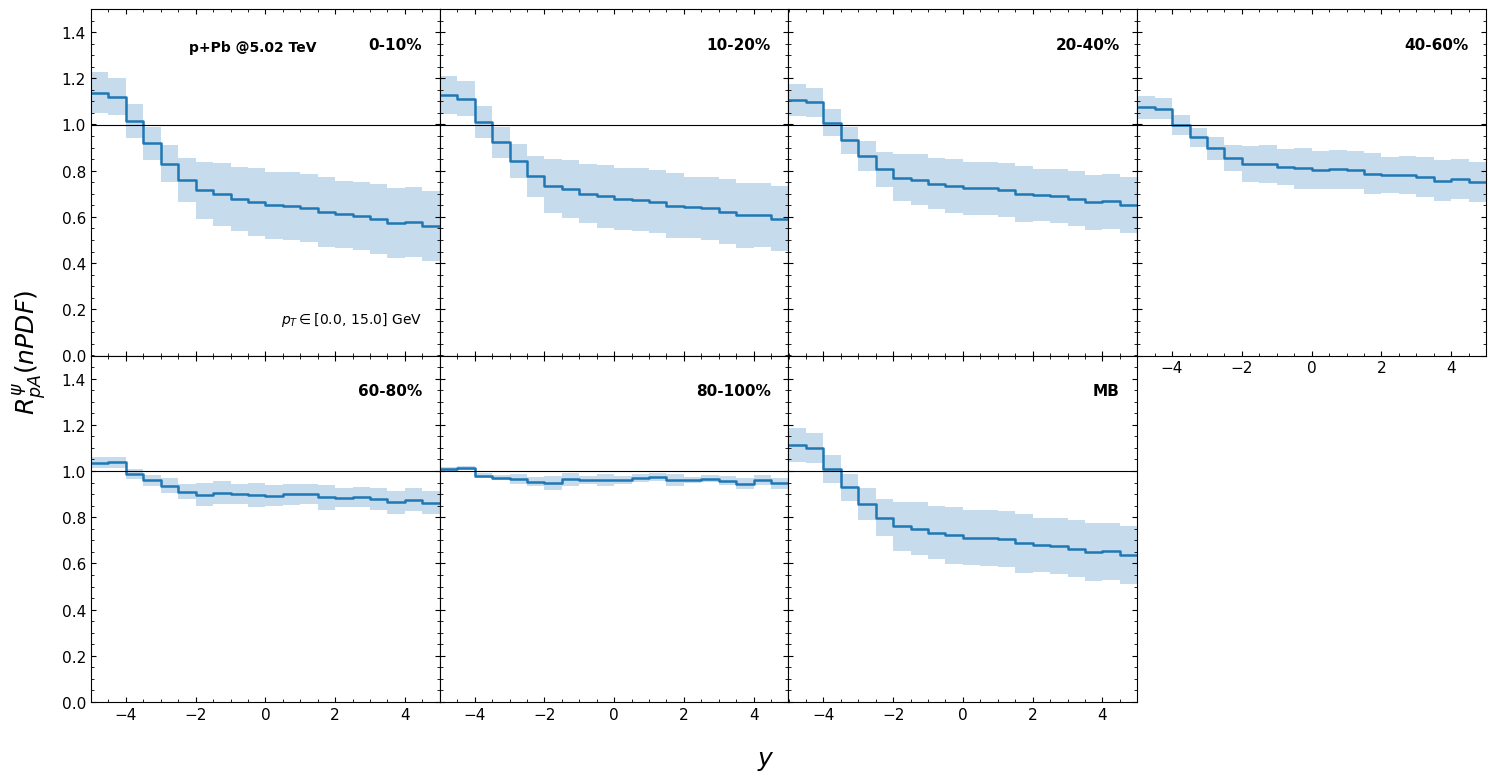

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Data retrieval for p+Pb @ 5.02 TeV
y_cent, tags_y, npdf_y = npdf_vs_y(ctx, Y_EDGES, PT_RANGE_AVG, include_mb=True)

# Layout: 2 rows, 4 columns (All panels will have identical size)
n_rows, n_cols = 2, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 9), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0, wspace=0) # Zero spacing for direct comparison
axes_flat = axes.flatten()

for ip, tag in enumerate(tags_y):
    ax = axes_flat[ip]
    Rc, Rlo, Rhi = npdf_y[tag]

    x_edges, y_c  = step_from_centers(y_cent, Rc)
    _,       y_lo = step_from_centers(y_cent, Rlo)
    _,       y_hi = step_from_centers(y_cent, Rhi)

    # --- Data Plotting (Consistent blue theme) ---
    ax.step(x_edges, y_c, where="post", lw=1.8, color="tab:blue")
    ax.fill_between(x_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=0.25, linewidth=0.0)
    ax.axhline(1.0, color="k", ls="-", lw=0.8)

    # --- Standardized Annotations ---
    # Centrality tag (Top Right)
    ax.text(0.95, 0.92, tag, transform=ax.transAxes, ha="right", va="top", weight='bold', fontsize=11)
    
    # Rapidity labels moved to bottom right per your preference
    if ip == 0:
        ax.text(0.95, 0.08, rf"$p_T \in [{PT_RANGE_AVG[0]:.1f},\,{PT_RANGE_AVG[1]:.1f}]$ GeV",
                transform=ax.transAxes, ha="right", va="bottom", color="black", fontsize=10)
    
    # Global Info (First panel only)
    if ip == 0:
        energy_label = rf"{ctx['sqrt_sNN']/1000:.2f} TeV" if ctx['sqrt_sNN'] > 500 else rf"{ctx['sqrt_sNN']:.0f} GeV"
        ax.text(0.28, 0.88, rf"p+Pb @{energy_label}", transform=ax.transAxes, weight='bold', fontsize=10)

    # --- Fixed Limits and Tick Formatting ---
    ax.set_xlim(-5.0, 5.0)
    ax.set_ylim(0.0, 1.50)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    
    ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=11)

    # --- Overlap Pruning for Equal-Sized Visuals ---
    y_labels = ax.get_yticklabels()
    if len(y_labels) > 0:
        y_labels[0].set_visible(False)  # Prune 0.2 to avoid X-axis overlap
        y_labels[-1].set_visible(False) # Prune 1.4 to avoid panel-above overlap

    # Prune right-most X label for all but the last column
    if (ip + 1) % n_cols != 0:
        x_labels = ax.get_xticklabels()
        if len(x_labels) > 0:
            x_labels[-1].set_visible(False)

    # Manual outer label control
    ax.tick_params(labelbottom=(ip >= 3), labelleft=(ip % n_cols == 0))

# Cleanly delete the 8th unused slot
if len(tags_y) < len(axes_flat):
    fig.delaxes(axes_flat[-1])

# Unified Global Axis Labels
fig.text(0.5, 0.04, r'$y$', ha='center', fontsize=18)
fig.text(0.08, 0.5, r'$R^{\psi}_{pA} (nPDF)$', va='center', rotation='vertical', fontsize=18)

if SAVE_PDF:
    fig.savefig(OUTDIR / f"RpA_nPDF_vs_y_{ctx['sqrt_sNN']}_TeV_FullGrid.pdf", bbox_inches="tight")
plt.show()

## $R_{pA}$ vs Transverse Momentum

In [10]:
def npdf_vs_pT(ctx, y_window, pt_edges, include_mb=True, mb_c0=MB_C0):
    y0, y1 = y_window
    wcent = make_centrality_weight_dict(ctx["cent_bins"], c0=mb_c0) if include_mb else None

    out = bin_rpa_vs_pT(
        ctx["df49_by_cent"], ctx["df_pp"], ctx["df_pa"], ctx["gluon"],
        cent_bins=ctx["cent_bins"],
        pt_edges=pt_edges,
        y_window=(y0, y1),
        weight_mode=WEIGHT_MODE,
        y_ref=Y_REF,
        pt_floor_w=PT_FLOOR_W,
        wcent_dict=wcent,
        include_mb=include_mb,
    )

    pT_cent = 0.5*(pt_edges[:-1] + pt_edges[1:])
    tags = tags_for_cent_bins(ctx["cent_bins"], include_mb=include_mb)
    bands = {
        tag: (np.asarray(out[tag]["r_central"], float),
              np.asarray(out[tag]["r_lo"], float),
              np.asarray(out[tag]["r_hi"], float))
        for tag in tags
    }
    return pT_cent, tags, bands

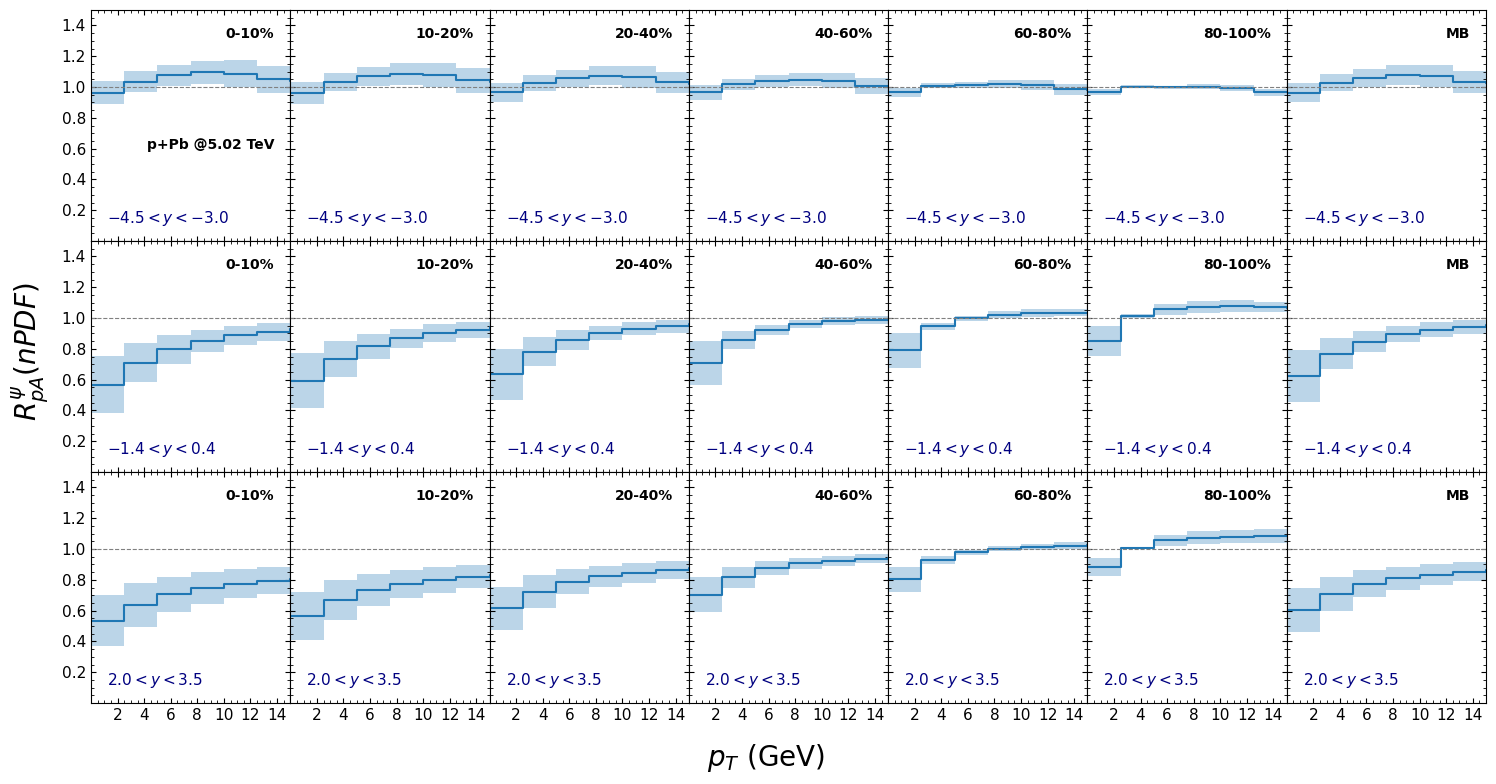

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

n_rows = len(Y_WINDOWS)
# Determine n_cols dynamically to ensure we capture Min-Bias and all centrality bins
pT_temp, tags_temp, _ = npdf_vs_pT(ctx, Y_WINDOWS[0][:2], P_EDGES, include_mb=True)
n_cols = len(tags_temp)

# --- BALANCE FIX: DIMENSIONS ---
# A width of 18 and height of (n_rows * 3) usually prevents vertical stretching.
# If panels still feel too tall, reduce the '3' to '2.5'.
fig_width = 18
panel_height = 3.0 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, panel_height * n_rows), 
                         sharex=True, sharey=True)
plt.subplots_adjust(hspace=0, wspace=0)

for row_idx, (y0, y1, y_name) in enumerate(Y_WINDOWS):
    pT_cent, tags_pt, npdf_pt = npdf_vs_pT(ctx, (y0, y1), P_EDGES, include_mb=True)
    
    for col_idx, tag in enumerate(tags_pt):
        if col_idx >= n_cols: break
        ax = axes[row_idx, col_idx]
        
        # --- Data Plotting ---
        Rc, Rlo, Rhi = npdf_pt[tag]
        x_edges, y_c  = step_from_centers(pT_cent, Rc)
        _,       y_lo = step_from_centers(pT_cent, Rlo)
        _,       y_hi = step_from_centers(pT_cent, Rhi)

        ax.step(x_edges, y_c, where="post", lw=1.5, color="tab:blue")
        ax.fill_between(x_edges, y_lo, y_hi, step="post", color="tab:blue", alpha=0.3, linewidth=0.0)
        ax.axhline(1.0, color="gray", ls="--", lw=0.8)
        
        # --- Clean Annotations ---
        # Rapidity: Only in the first panel of each row to reduce clutter
        ax.text(0.08, 0.08, rf"${y0:.1f} < y < {y1:.1f}$", transform=ax.transAxes, 
                    color="navy", fontsize=11, fontweight='bold', 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
        
        # Centrality/MB Tag: Top Right of every panel
        ax.text(0.92, 0.88, tag, transform=ax.transAxes, ha="right", weight='bold', fontsize=10)
        
        # Global Info: Only Top-Left panel
        if row_idx == 0 and col_idx == 0:
            energy_label = rf"{ctx['sqrt_sNN']/1000:.2f} TeV" if ctx['sqrt_sNN'] > 500 else rf"{ctx['sqrt_sNN']:.0f} GeV"
            ax.text(0.28, 0.40, rf"p+Pb @{energy_label}", transform=ax.transAxes, weight='bold',fontsize=10)

        # --- Axis Limits & Formatting ---
        ax.set_xlim(0, 15.0) # Standardized for pPb
        ax.set_ylim(0.0, 1.50)
        
        # Consistent Tick Spacing
        ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
        
        # --- Overlap Removal ---
        # Pruning the 'both' (min and max) labels is essential when hspace/wspace = 0
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8, prune='both'))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=9, prune='both'))
        
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)
        ax.label_outer() 

# Global Axis Labels
fig.text(0.5, 0.04, r'$p_T$ (GeV)', ha='center', fontsize=20)
fig.text(0.08, 0.5, r'$R^{\psi}_{pA} (nPDF)$', va='center', rotation='vertical', fontsize=20)

if SAVE_PDF:
    plt.savefig(OUTDIR / f"RpA_nPDF_vs_pT_{ctx['sqrt_sNN']}_TeV_FullGrid.pdf", bbox_inches="tight")
plt.show()